In [2]:
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm

In [3]:
data = pd.read_excel('/data/UDDS-US06.xlsx', header=None)
normal, highway = data[1], data[3]
normal.name = highway.name = 'speed'

In [7]:
highway = highway.dropna()

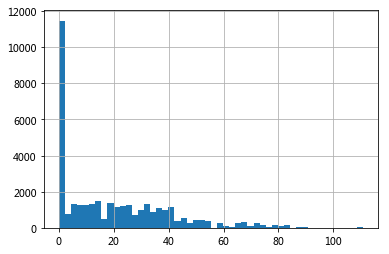

In [10]:
highway.hist(bins=50)

In [13]:
from tqdm import tqdm
from pathlib import Path

excel_files = (Path.cwd() / 'excel').glob('*.xlsx')
for file in tqdm(excel_files):
    data = pd.read_excel(file, header=None)
    break

0it [00:00, ?it/s]


In [14]:
data

,0,1
0,0,-5365.256125
1,30,-12696.547884
2,60,-10840.757238
3,90,-8011.135857
4,120,-5420.378619
...,...,...
2395,71850,-9040.089087
2396,71880,-7533.407572
2397,71910,-16353.006682
2398,71940,-10197.661470


### 功率分布可视化

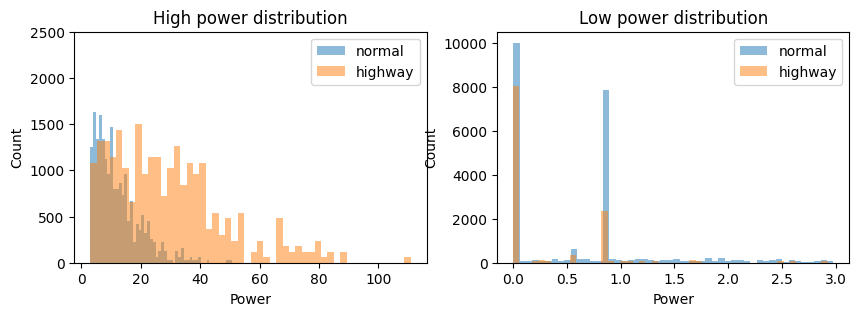

In [3]:
f, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(normal[normal>3], alpha=0.5, bins=50, label='normal')
axes[0].hist(highway[highway>3], alpha=0.5, bins=50, label='highway')
axes[0].legend()
axes[0].set_ylim([0, 2500])
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Power')
axes[0].set_title('High power distribution')

axes[1].hist(normal[normal < 3], alpha=0.5, bins=50, label='normal')
axes[1].hist(highway[highway < 3], alpha=0.5, bins=50, label='highway')
axes[1].legend()
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Power')
axes[1].set_title('Low power distribution')

plt.show()

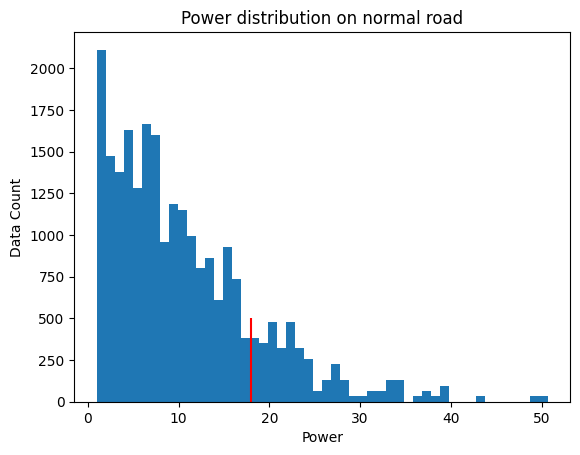

In [4]:
plt.hist(normal[normal > 1], bins=50)
plt.vlines([18], ymin = 0, ymax=500, color='r')
plt.ylabel('Data Count')
plt.xlabel('Power')
plt.title('Power distribution on normal road')
plt.show()

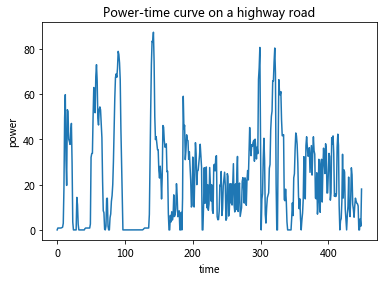

In [4]:
highway.iloc[0:450].plot()
plt.ylabel('power')
plt.xlabel('time')
plt.title('Power-time curve on a highway road')
plt.show()

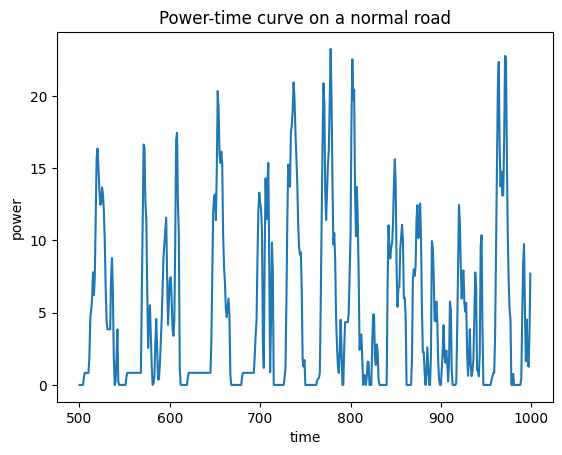

In [6]:
normal.iloc[500:1000].plot()
plt.ylabel('power')
plt.xlabel('time')
plt.title('Power-time curve on a normal road')
plt.show()

## Using an HMM to fit the data (highway)

In [5]:
def sample_hmm(model, n):
    x, _ = model.sample(n)
    x = np.abs(x.squeeze()) // 2 * 2
    to_cut = model.means_.max() + model.covars_.squeeze()[model.means_.squeeze().argmax()]
    if to_cut > x.max():
        to_cut = x.max()
    x[x > to_cut] = to_cut
    x *= 16.5 / to_cut
    return x

def discretize(samples, interval=30):
    data = np.abs(samples.squeeze()) // 2 * 2
    res = np.zeros_like(data)
    for i in range(len(data)):
        j =  i // interval
        mean = data[j * interval: (j+1) * interval].mean()
        res[i] = mean
    return res

def sample_and_discretize(model, n, interval=30, return_original=False):
    data, _ = model.sample(n)
    data = np.abs(data.squeeze()) // 2 * 2
    if return_original:
        return data

    res = np.zeros_like(data)
    for i in range(len(data)):
        j =  i // interval
        mean = data[j * interval: (j+1) * interval].mean()
        res[i] = mean
    to_cut = model.means_.max() + model.covars_.squeeze()[
        model.means_.squeeze().argmax()]
    if to_cut > res.max():
        to_cut = res.max()
    res[res > to_cut] = to_cut
    res *= 16.5 / to_cut  # To match the power limit of test machine
    return res

In [154]:
highway_processed = highway.copy(deep=True)[:450]
fraction_to_keep = 0.5
to_train = []
for x in highway_processed:
    if x > 1 or random.random() <= fraction_to_keep:
        to_train.append(x)
        
n_components = 5
highway_model = hmm.GaussianHMM(n_components=n_components, covariance_type="full", n_iter=100)
highway_model.fit(np.array(to_train).reshape(-1, 1))

GaussianHMM(covariance_type='full', n_components=5, n_iter=100)

In [27]:
with open('hmm.pkl', 'wb') as f:
    pickle.dump(highway_model, f)

In [7]:
with open('hmm.pkl', 'rb') as f:
    highway_model = pickle.load(f)

In [8]:
from tqdm.notebook import tqdm

highway_processed = highway.copy(deep=True)[:450]


# Sample from the HMM, organized into [N, L]
samples = 100
sample_dim = 10000
sampled = np.array([
    sample_and_discretize(
        highway_model, sample_dim, return_original=True
    ) for _ in tqdm(range(samples), desc='Sample from HMM')
])

In [9]:
# Calculate the histogram of each sample
n_bins = 44
histograms = []
hist_range = (0, max(highway_processed.values))
for data in tqdm(sampled, desc='Calculate histograms'):
    hist_, bins = np.histogram(data, range=hist_range, bins=n_bins)
    histograms.append(hist_)


# Calculate the raw histogram, sub-sampled the zeros
fraction_to_keep = 0.15
to_train = []
for x in highway_processed:
    if x > 1 or random.random() <= fraction_to_keep:
        to_train.append(x)
gt_hist, bins = np.histogram(to_train, range=hist_range, bins=n_bins)

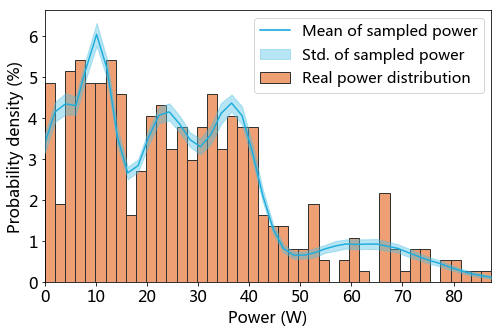

In [10]:
mean_color = '#00A3DA'
std_color = '#4DC0E3'
hist_color = '#EE9F74'

means = np.mean(histograms, axis=0)
stds = np.std(histograms, axis=0)
means_count = means.sum()
gt_count = gt_hist.sum()

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.rcParams['font.size'] = 16
fig, ax = plt.subplots(figsize=(8, 5))

x = np.linspace(*hist_range, n_bins)
ax.bar(
    bin_centers,
    gt_hist/gt_count * 100,
    width=bins[1]-bins[0],
    color=hist_color,
    edgecolor='#333333',
    label='Real power distribution')
ax.plot(
    x, means / means_count * 100, color=mean_color, label='Mean of sampled power')
ax.fill_between(
    x,
    (means + stds) / means_count * 100,
    (means - stds) / means_count * 100,
    color=std_color,
    alpha=0.4,
    zorder=10,
    label='Std. of sampled power'
)
ax.set_ylabel('Probability density (%)')
ax.set_xlabel('Power (W)')

ax.legend(fontsize=15)
ax.set_xlim(hist_range)

plt.show()

In [18]:
fmt='%f'
np.savetxt('./data_to_plot/x.txt', x / max(x) * 16.5, fmt=fmt)
np.savetxt('./data_to_plot/means.txt', means, fmt=fmt)
np.savetxt('./data_to_plot/stds.txt', stds, fmt=fmt)
np.savetxt('./data_to_plot/means_count.txt', np.array(int(means_count), dtype=int)[None], fmt='%d')
np.savetxt('./data_to_plot/true.txt', gt_hist, fmt='%d')
np.savetxt('./data_to_plot/true_count.txt', np.array(int(gt_count))[None], fmt='%d')

In [21]:
def plot_mean_std_histograms(data, bins=30):
    """
    For each row in the data, calculate the histogram and then plot the mean and standard deviation of these histograms.

    Parameters:
    data (numpy.ndarray): The input data of shape [N, L].
    bins (int): The number of bins to use for the histograms.
    """
    # Calculate histograms for each row in the data
    histograms = np.array([np.histogram(row, bins=bins, range=(data.min(), data.max()))[0] for row in data])

    # Calculate the mean and standard deviation of the histograms
    hist_means = np.mean(histograms, axis=0)
    hist_stds = np.std(histograms, axis=0)
    bin_edges = np.linspace(data.min(), data.max(), bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Create the plot
    plt.figure(figsize=(10, 6))

    # Plotting the mean of the histograms
    plt.plot(bin_centers, hist_means, label='Mean of Histograms', color='red')

    # Adding the standard deviation as a shadowed area
    plt.fill_between(bin_centers, hist_means - hist_stds, hist_means + hist_stds, color='red', alpha=0.2)

    plt.title('Mean and Standard Deviation of Histograms Over Rows')
    plt.xlabel('Bin Centers')
    plt.ylabel('Histogram Values')
    plt.legend()
    plt.show()

In [88]:
highway_processed = highway.copy(deep=True)[:450]
discretized = sample_and_discretize(highway_model, 10000)
fitted = sample_and_discretize(highway_model, 12000, return_original=True)

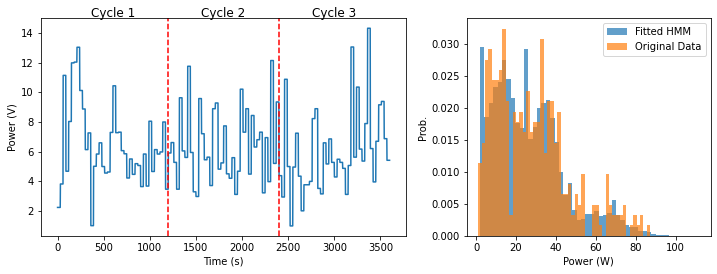

In [91]:
fig, (cycle_ax, dist_ax) = plt.subplots(
    1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [3, 2]})
segments = 1200
cycle_ax.plot(discretized[:segments * 3])
cycle_ax.axvline(segments, color='red', linestyle='--')
cycle_ax.axvline(segments * 2, color='red', linestyle='--')
cycle_ax.set_ylabel('Power (V)')
cycle_ax.set_xlabel('Time (s)')

cycle_ax.text(
    segments / 2, np.max(discretized) * 0.8,
    'Cycle 1', ha='center', va='bottom', fontsize=12)
cycle_ax.text(
    segments + segments / 2, np.max(discretized) * 0.8,
    'Cycle 2', ha='center', va='bottom', fontsize=12)
cycle_ax.text(
    segments * 2 + segments / 2, np.max(discretized) * 0.8,
    'Cycle 3', ha='center', va='bottom', fontsize=12)

bins = 50
alpha = 0.7

dist_ax.hist(fitted[fitted > 1], bins=bins, density=True, alpha=alpha, label='Fitted HMM')
dist_ax.hist(highway_processed[highway_processed > 1],
         bins=bins, density=True, alpha=alpha, label='Original Data')
dist_ax.legend()
dist_ax.set_ylabel('Prob.')
dist_ax.set_xlabel('Power (W)')

plt.show()